# 📊 Exploratory Data Analysis (EDA)

## 🛍️ Project Title
**Amazon Product Sales - Exploratory Data Analysis**

---

## 🎯 Objective
The objective of this project is to explore the cleaned Amazon product sales dataset to uncover meaningful patterns, trends, and insights. This analysis aims to understand product pricing, customer ratings, reviews, discounts, product categories and delivery trends through statistical summaries and visualizations. The findings can help identify factors that influence product popularity and sales performance.

---

## 📁 Dataset Description
The dataset contains cleaned information about Amazon products collected from an e-commerce platform. It includes product details, pricing, discounts, customer ratings, reviews, product categories, delivery details, and other relevant attributes.

### Key Features
- Product Name
- Main Category
- Rating
- Review count
- Unit sold
- Discounted Price
- Original Price
- ***Discount Percentage****
- Best seller
- Delivery Date
- Delivery Day
- Delivery Month
- And other cleaned product-related attributes

The dataset has already undergone data cleaning and preprocessing to handle missing values, inconsistent formats, duplicate records, and incorrect data types.

---

## ❓ Questions to Answer

***Product Analysis***
- Which product categories contain the highest number of products?
- What are the most common product categories?

***Pricing Analysis***
- What is the distribution of discounted prices?
- Which categories have the highest average discounted price?
- Which products receive the highest discounts?
- Is there a relationship between original price and discounted price?

***Rating & Review Analysis***
- How are product ratings distributed?
- Which categories have the highest average ratings?
- Which products have the largest number of ratings and reviews?
- Do highly rated products receive more reviews?
***Discount Analysi***
- Which categories offer the highest discounts?
- Is there a relationship between discount percentage and product ratings?
- Do larger discounts lead to more customer reviews?

***Delivery Analysis***
- Which delivery day occurs most frequently?
- Are products delivered more often in specific months?

***Correlation Analysis***
- Is there a relationship between price and rating?
- Does review count increase with rating count?
- Which numerical features are strongly correlated?

***Overall Insights***
- What are the key trends and patterns in the dataset?
- What business insights can be derived from the analysis?
- What recommendations can improve product performance and customer engagement?

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading Clean Dataset
df = pd.read_csv('C:/Users/Admin/DataScienceCourse/Amazon_Project/data/Interim/amazon_product_sales_cleaned.csv')

In [3]:
# changing datatype
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'])

In [4]:
# overview
df.head()

,product_title,product_category,product_rating,review_count,units_sold_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_couponed,buy_box_availability,delivery_date,delivery_month,delivery_day,image_url,product_url,data_collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,Smartphones,4.6,375,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,September,Monday,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",Smartphones,4.3,2457,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,August,Friday,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",Smartphones,4.6,3044,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,September,Monday,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Headphones & Earbuds,4.6,35882,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,Not Available,NaT,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,Smartphones,4.8,28988,10000.0,72.74,72.74,No Badge,Organic,No Coupon,Not Available,NaT,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29


## Dataset Overview

In [5]:
# Shape
df.shape

(40135, 17)

In [6]:
# columns
df.columns

Index(['product_title', 'product_category', 'product_rating', 'review_count',
       'units_sold_last_month', 'discounted_price', 'original_price',
       'is_best_seller', 'is_sponsored', 'has_couponed',
       'buy_box_availability', 'delivery_date', 'delivery_month',
       'delivery_day', 'image_url', 'product_url', 'data_collected_at'],
      dtype='object')

In [7]:
# Datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40135 entries, 0 to 40134
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   product_title          40135 non-null  object        
 1   product_category       40135 non-null  object        
 2   product_rating         39118 non-null  float64       
 3   review_count           40135 non-null  int64         
 4   units_sold_last_month  30357 non-null  float64       
 5   discounted_price       39993 non-null  float64       
 6   original_price         39993 non-null  float64       
 7   is_best_seller         40135 non-null  object        
 8   is_sponsored           40135 non-null  object        
 9   has_couponed           40135 non-null  object        
 10  buy_box_availability   40135 non-null  object        
 11  delivery_date          30692 non-null  datetime64[ns]
 12  delivery_month         30692 non-null  object        
 13  d

In [8]:
# Missing Values
df.isnull().sum()

product_title               0
product_category            0
product_rating           1017
review_count                0
units_sold_last_month    9778
discounted_price          142
original_price            142
is_best_seller              0
is_sponsored                0
has_couponed                0
buy_box_availability        0
delivery_date            9443
delivery_month           9443
delivery_day             9443
image_url                   0
product_url              2004
data_collected_at           0
dtype: int64

In [9]:
# Duplicated rows
df.duplicated().sum()

np.int64(0)

In [10]:
# summary statistics
df.describe()

,product_rating,review_count,units_sold_last_month,discounted_price,original_price,delivery_date,data_collected_at
count,39118.000000,40135.000000,30357.000000,39993.000000,39993.000000,30692,40135
mean,4.408899,2959.789710,1350.085647,207.981149,222.587955,2025-09-04 06:42:02.298970368,2025-08-26 11:31:20.296100864
min,1.000000,0.000000,50.000000,2.160000,2.160000,2025-08-27 00:00:00,2025-08-21 11:14:29
25%,4.200000,76.000000,100.000000,28.990000,30.990000,2025-09-02 00:00:00,2025-08-24 21:56:14
50%,4.500000,336.000000,200.000000,79.990000,85.990000,2025-09-03 00:00:00,2025-08-25 11:26:46
75%,4.700000,1845.000000,400.000000,216.660000,219.000000,2025-09-04 00:00:00,2025-08-29 11:21:10
max,5.000000,865598.000000,100000.000000,4699.000000,5399.000000,2025-09-29 00:00:00,2025-08-30 19:56:33
std,0.383922,13058.868528,6463.762206,356.690530,388.828782,NaN,NaN


## Column Types

- **Numerical** - product_rating , review_count , unit_sold_last_month , discounted_price , original_price 
- **Categorical** - product_category , is_best_seller , is_sponsored , has_couponed , buy_box_availability , delivery_day , delivery_month 
- **datetime** - delivery_date

## Univariate Analysis

### Numerical Columns

#### Product_rating
**conclusions**

- mostly all product has rating greater than 4
- Very few products have low ratings
- The product_rating distribution is highly negatively skewed
- There are no outliers above the upper whisker. But low-rated products are treated as outliers.
- 2 % missing values 

In [11]:
# Statistical Summary (min,max,mean,median,std,quantile)
df['product_rating'].describe()

count    39118.000000
mean         4.408899
std          0.383922
min          1.000000
25%          4.200000
50%          4.500000
75%          4.700000
max          5.000000
Name: product_rating, dtype: float64

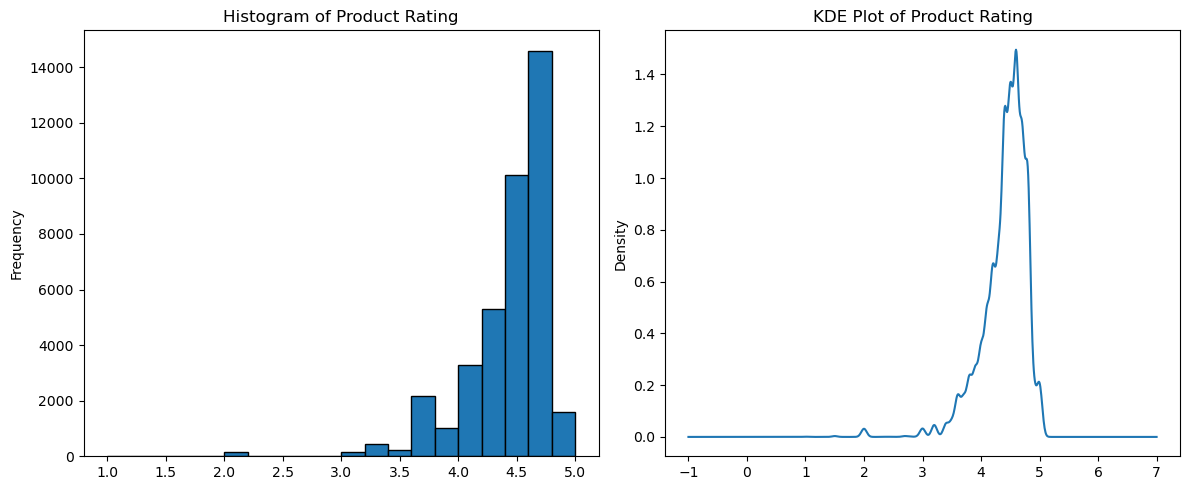

In [12]:
# Distribution Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
df["product_rating"].plot(
    kind="hist",
    bins=20,
    edgecolor="black",
    ax=ax[0],
    title="Histogram of Product Rating"
)

# KDE Plot
df["product_rating"].plot(
    kind="kde",
    ax=ax[1],
    title="KDE Plot of Product Rating"
)

plt.tight_layout()
plt.show()

<Axes: >

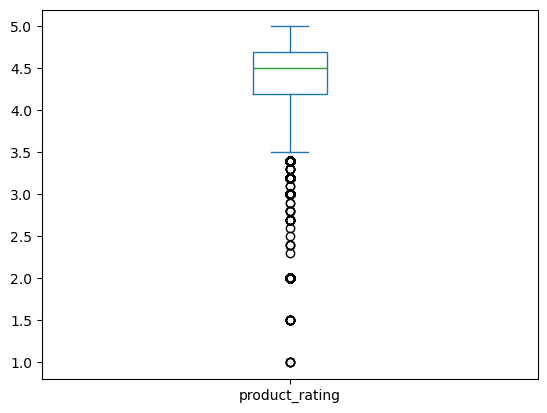

In [13]:
# Box plot
df['product_rating'].plot(kind='box')

In [14]:
# skewness
df['product_rating'].skew()

np.float64(-1.930110770693947)

In [15]:
# Outliers
df[df['product_rating'] < 3.5].shape
# There are no outliers above the upper whisker.
# But low-rated products are treated as outliers.

(767, 17)

In [16]:
# missing values
df['product_rating'].isnull().sum()/len(df['product_rating'])*100

np.float64(2.5339479257505917)

#### Review_count
**conclusions**

- highly skewed data
- no missing value

In [17]:
# Statistical Summary
df['review_count'].describe()

count     40135.000000
mean       2959.789710
std       13058.868528
min           0.000000
25%          76.000000
50%         336.000000
75%        1845.000000
max      865598.000000
Name: review_count, dtype: float64

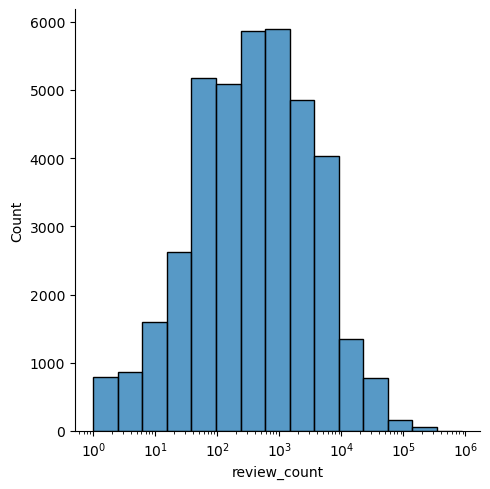

In [18]:
# Distribution Plot
sns.displot(data=df,kind='hist',x='review_count',bins=15,log_scale=True)

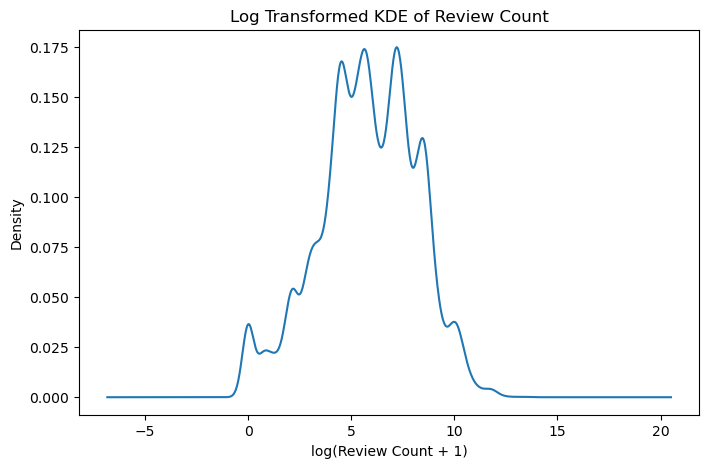

In [19]:
# Log transformation
review_count_log = np.log1p(df["review_count"])
# kde plot
plt.figure(figsize=(8,5))
review_count_log.plot(kind="kde")
plt.title("Log Transformed KDE of Review Count")
plt.xlabel("log(Review Count + 1)")
plt.show()

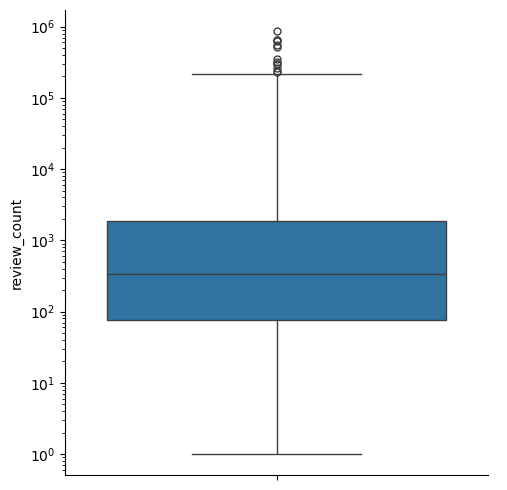

In [20]:
# outliers 
sns.catplot(data=df,kind='box',y='review_count',log_scale=True)

In [21]:
# skewness
df['review_count'].skew()

np.float64(25.037315142693682)

In [22]:
# missing values
df['review_count'].isnull().sum()/len(df['review_count'])*100

np.float64(0.0)

#### units_sold_last_month
**conclusions**

- highly skewed
- outliers present
- 24 % values are missing

In [23]:
# Statistical Summary
df['units_sold_last_month'].describe()

count     30357.000000
mean       1350.085647
std        6463.762206
min          50.000000
25%         100.000000
50%         200.000000
75%         400.000000
max      100000.000000
Name: units_sold_last_month, dtype: float64

Text(0.5, 1.0, 'Log Transformed Distribution of Units Sold')

<Figure size 800x500 with 0 Axes>

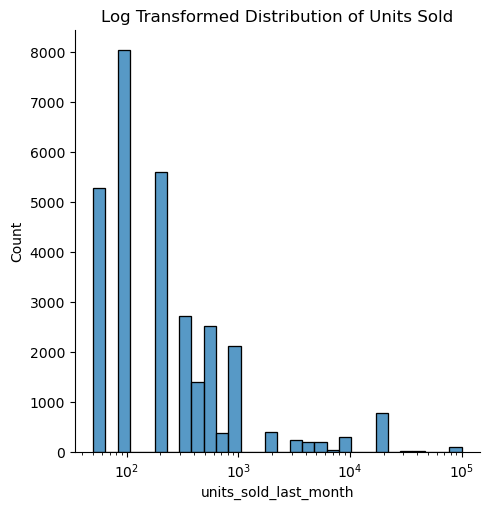

In [24]:
# Distribution Plot
plt.figure(figsize=(8,5))
sns.displot(data=df,kind='hist',x='units_sold_last_month',bins=30,log_scale=True)
plt.title("Log Transformed Distribution of Units Sold")

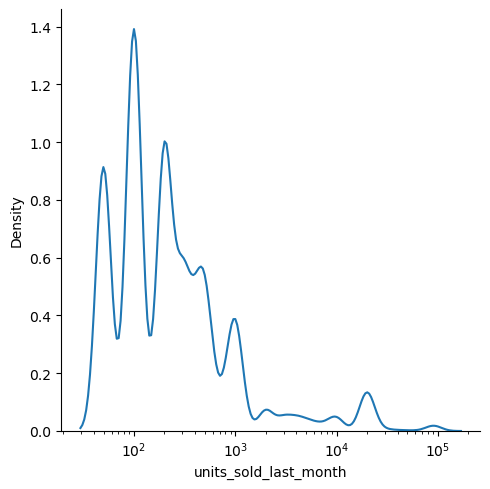

In [25]:
# Kde plot
sns.displot(data=df,kind='kde',x='units_sold_last_month',log_scale=True)

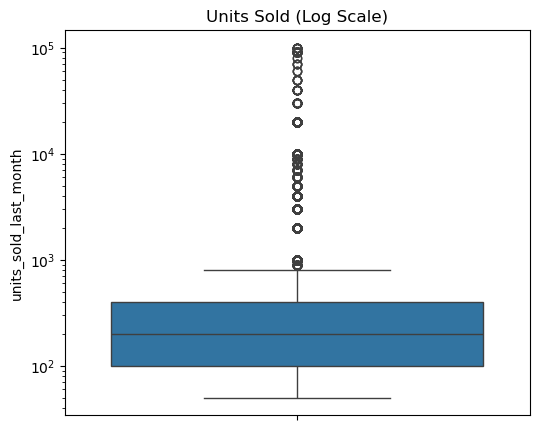

In [26]:
# Box Plot on Log Scale
plt.figure(figsize=(6,5))
sns.boxplot(y=df["units_sold_last_month"])
plt.yscale("log")
plt.title("Units Sold (Log Scale)")
plt.show()

In [27]:
# skewness
df['units_sold_last_month'].skew()

np.float64(10.45759854199748)

In [28]:
# Outliers
df[df['units_sold_last_month']>1000].shape

(2315, 17)

In [29]:
# Missing values
df['units_sold_last_month'].isnull().sum()/len(df['units_sold_last_month'])*100

np.float64(24.362775632241185)

#### discounted_price
**conclusions**

- highly skewed data
- most price range between Rs.0 to 500
- some missing value 0.35%

In [30]:
# Statistical Summary
df['discounted_price'].describe()

count    39993.000000
mean       207.981149
std        356.690530
min          2.160000
25%         28.990000
50%         79.990000
75%        216.660000
max       4699.000000
Name: discounted_price, dtype: float64

Text(0.5, 1.0, 'Log Transformed Distribution of discounted price')

<Figure size 800x500 with 0 Axes>

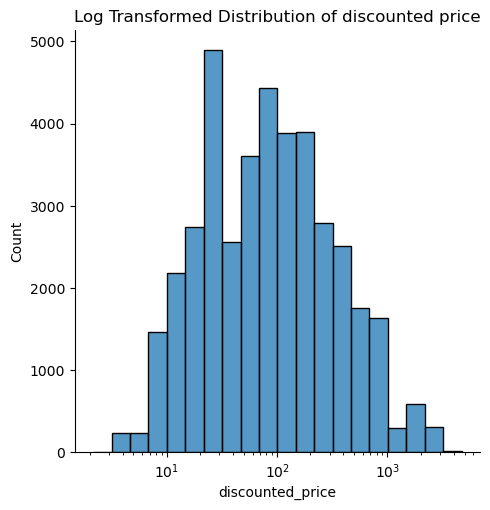

In [31]:
# Distribution Plot
plt.figure(figsize=(8,5))
sns.displot(data=df,kind='hist',x='discounted_price',bins=20,log_scale=True)
plt.title("Log Transformed Distribution of discounted price")

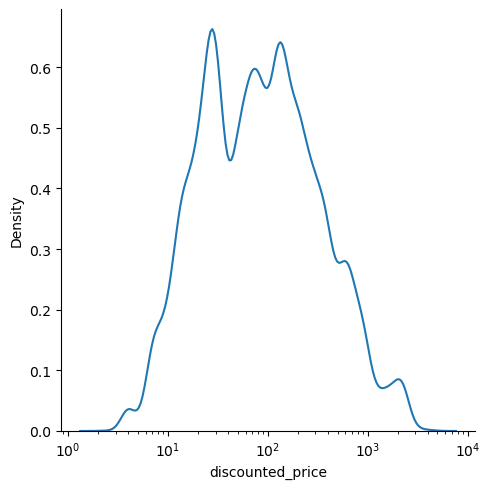

In [32]:
# Kde plot
sns.displot(data=df,kind='kde',x='discounted_price',log_scale=True)

<Axes: >

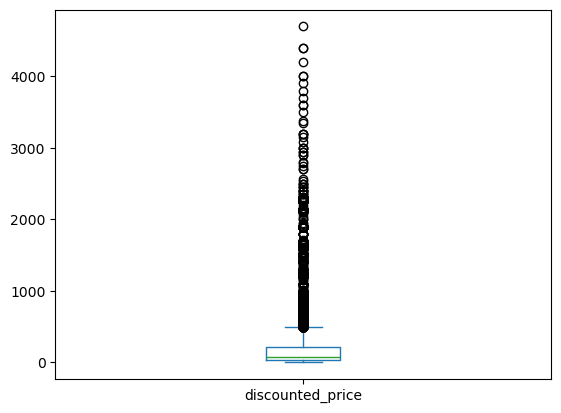

In [33]:
# Box plot
df['discounted_price'].plot(kind='box')

In [34]:
# Price Range Analysis
price_bins = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,
              2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000,
              df['discounted_price'].max()
]
price_labels = ['₹0-250','₹251-500','₹501-750','₹751-1000','₹1001-1250','₹1251-1500','₹1501-1750',
                '₹1751-2000','₹2001-2250','₹2251-2500','₹2501-2750','₹2751-3000','₹3001-3250',
                '₹3251-3500','₹3501-3750','₹3751-4000','Above ₹4000'
]
price_range = pd.cut(
    df['discounted_price'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)
price_range.value_counts().sort_index()

discounted_price
₹0-250         31114
₹251-500        4590
₹501-750        1955
₹751-1000       1142
₹1001-1250       198
₹1251-1500       100
₹1501-1750       267
₹1751-2000       155
₹2001-2250       152
₹2251-2500       287
₹2501-2750         5
₹2751-3000         9
₹3001-3250         5
₹3251-3500         3
₹3501-3750         3
₹3751-4000         4
Above ₹4000        4
Name: count, dtype: int64

In [35]:
# skewness
df['discounted_price'].skew()

np.float64(3.8669334493969187)

In [36]:
# Outliers
df[df['discounted_price'] > 2500].shape

(33, 17)

In [37]:
# missing value
df['discounted_price'].isnull().sum()/len(df['discounted_price'])*100

np.float64(0.35380590507038745)

#### original_price
**conclusions**

- highly skewed data
- most price range between Rs.0 to 500
- some missing value 0.35%

In [38]:
# Statistical Summary
df['original_price'].describe()

count    39993.000000
mean       222.587955
std        388.828782
min          2.160000
25%         30.990000
50%         85.990000
75%        219.000000
max       5399.000000
Name: original_price, dtype: float64

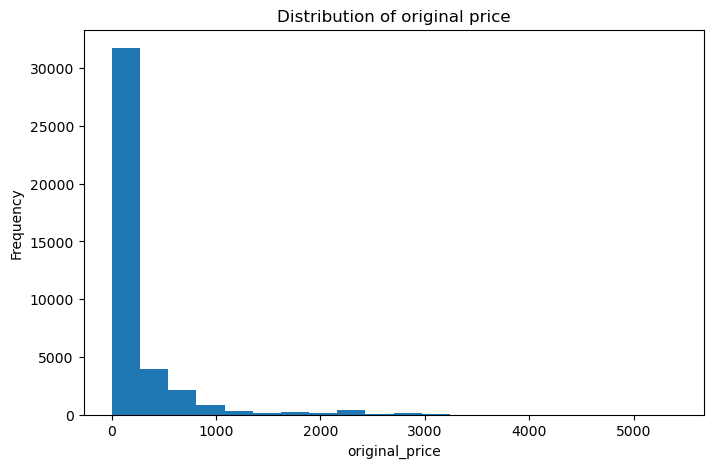

In [39]:
# Distribution Plot
plt.figure(figsize=(8,5))
df['original_price'].plot(kind='hist',bins=20)
plt.title("Distribution of original price")
plt.xlabel("original_price")
plt.show()

<Axes: ylabel='Density'>

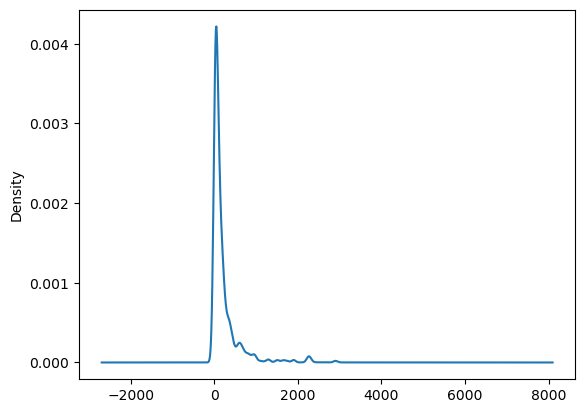

In [40]:
# Kde plot
df['original_price'].plot(kind='kde')

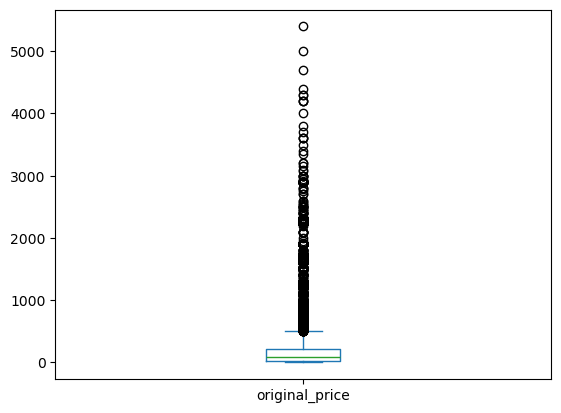

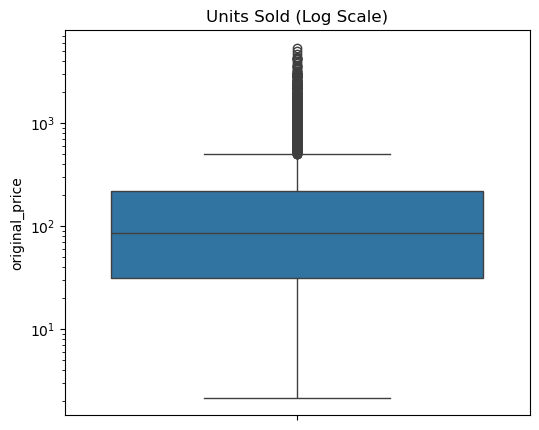

In [41]:
# Box plot
df['original_price'].plot(kind='box')
# Box Plot on Log Scale
plt.figure(figsize=(6,5))
sns.boxplot(y=df["original_price"])
plt.yscale("log")
plt.title("Units Sold (Log Scale)")
plt.show()

In [42]:
# Price Range Analysis
price_bins = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000,
              2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000,
              df['original_price'].max()
]
price_labels = ['₹0-250','₹251-500','₹501-750','₹751-1000','₹1001-1250','₹1251-1500','₹1501-1750',
                '₹1751-2000','₹2001-2250','₹2251-2500','₹2501-2750','₹2751-3000','₹3001-3250',
                '₹3251-3500','₹3501-3750','₹3751-4000','Above ₹4000'
]
price_range = pd.cut(
    df['original_price'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)
price_range.value_counts().sort_index()

original_price
₹0-250         30937
₹251-500        4579
₹501-750        1949
₹751-1000       1141
₹1001-1250       129
₹1251-1500       240
₹1501-1750       293
₹1751-2000       153
₹2001-2250       149
₹2251-2500       289
₹2501-2750         9
₹2751-3000       102
₹3001-3250         5
₹3251-3500         3
₹3501-3750         4
₹3751-4000         2
Above ₹4000        9
Name: count, dtype: int64

In [43]:
# Outliers
df[df['discounted_price'] > 2500].shape

(33, 17)

In [44]:
# skewness
df['original_price'].skew()

np.float64(4.001970529477833)

In [45]:
# missing value
df['original_price'].isnull().sum()/len(df['original_price'])*100

np.float64(0.35380590507038745)

### Categorical Columns

#### product_category
**conclusions**

- 23 unique categories
- most values are in `Other` category
- no missing value

In [47]:
# value counts
df['product_category'].value_counts()

product_category
Other                       7636
Desktop Components          4007
Headphones & Earbuds        3872
Computer Accessories        3280
Batteries                   3179
Laptops                     2915
Smartphones                 2596
Microphones                 2024
Camera Accessories          1941
Printers                    1933
Networking                  1251
Tablets                     1092
Storage Devices              877
TV & Display Accessories     620
Memory Cards                 580
Office Supplies              507
Printer Ink                  474
Accessories                  438
Cables & Chargers            385
Gaming Accessories           238
Streaming Devices            135
Smartwatches                  88
Calculators                   67
Name: count, dtype: int64

In [48]:
# number of unique categories
df['product_category'].nunique()

23

<Axes: xlabel='product_category'>

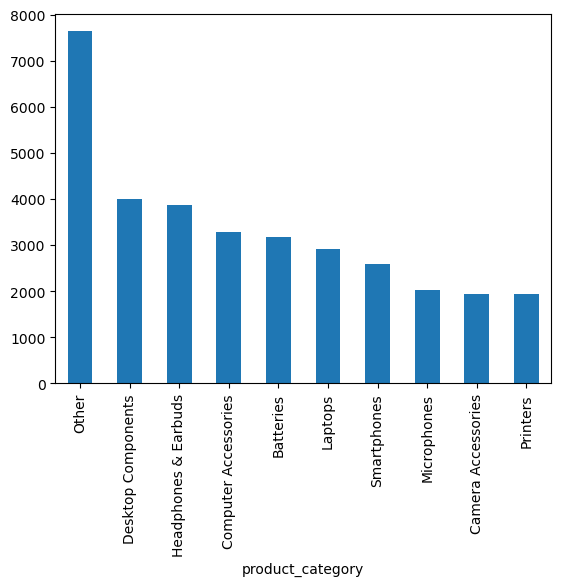

In [50]:
# Bar Chart (Top Categories)
df['product_category'].value_counts().head(10).plot(kind='bar')

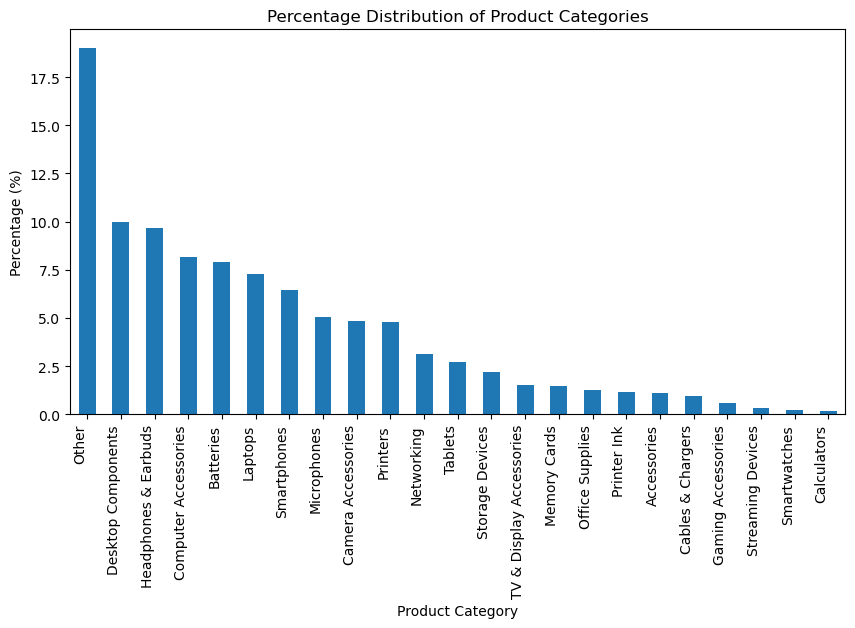

In [55]:
# Bar chart of percentage distributions 
(
    df['product_category']
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind='bar', figsize=(10, 5))
)

plt.title('Percentage Distribution of Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90, ha='right')
plt.show()

In [60]:
# missing value
df['product_category'].isnull().sum()/len(df['product_category'])*100

np.float64(0.0)

#### is_best_seller
**conclusions**

- almost 95% value has `No Badge`
- No missing values

In [61]:
# value counts
df['is_best_seller'].value_counts()

is_best_seller
No Badge             38297
Amazon's               731
Limited time deal      409
Best Seller            265
Save 30%               125
Ends in                 97
Save 10%                61
Save 18%                57
Save 17%                51
Save 12%                26
Save 9%                 14
Save 77%                 2
Name: count, dtype: int64

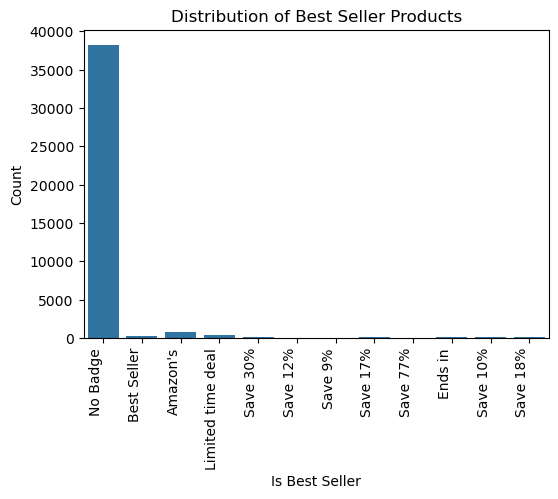

In [67]:
# Count plot
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='is_best_seller'
)

plt.title('Distribution of Best Seller Products')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Is Best Seller')
plt.ylabel('Count')

plt.show()

In [66]:
# Percentage Distribution
category_percentage = (
    df['is_best_seller']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

category_percentage.columns = ['is_best_seller', 'Percentage (%)']

category_percentage

,is_best_seller,Percentage (%)
0,No Badge,95.42
1,Amazon's,1.82
2,Limited time deal,1.02
3,Best Seller,0.66
4,Save 30%,0.31
5,Ends in,0.24
6,Save 10%,0.15
7,Save 18%,0.14
8,Save 17%,0.13
9,Save 12%,0.06


In [68]:
# missing value
df['is_best_seller'].isnull().sum()/len(df['is_best_seller'])*100

np.float64(0.0)

#### is_sponsored
**conclusions**

- 82 % values are in `Organic`
- No missing values

In [69]:
# Value Counts
df['is_sponsored'].value_counts()

is_sponsored
Organic      33136
Sponsored     6999
Name: count, dtype: int64

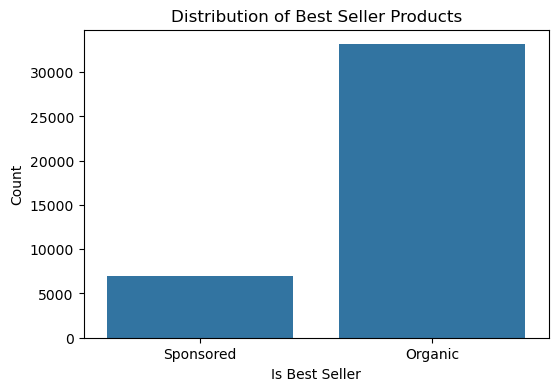

In [72]:
# Count plot
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='is_sponsored'
)
plt.title('Distribution of Best Seller Products')
plt.xlabel('Is Best Seller')
plt.ylabel('Count')
plt.show()

In [80]:
# Percentage Distribution
category_percentage = (
    df['is_sponsored']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
category_percentage.columns = ['is_sponsored', 'Percentage (%)']
category_percentage

,is_sponsored,Percentage (%)
0,Organic,82.56
1,Sponsored,17.44


In [79]:
# missing value
df['is_sponsored'].isnull().sum()/len(df['is_sponsored'])*100

np.float64(0.0)

#### has_couponed
**conclusions**

- Almost 95 % value has 'No Coupon`
- No missing Values 

In [83]:
# Value Counts
df['has_couponed'].value_counts().head(15)

has_couponed
No Coupon                    38187
Save $16.00  with coupon       438
Save 15%  with coupon          398
Save 10%  with coupon          218
Save 5%  with coupon           191
Save 50%  with coupon          123
Save $11.00  with coupon       120
Save $100.00  with coupon       97
Save 40%  with coupon           96
Save $25.00  with coupon        65
Save $30.00  with coupon        49
Save $69.00  with coupon        31
Save 8%  with coupon            18
Save $10.00  with coupon        14
Save $33.00  with coupon        13
Name: count, dtype: int64

In [85]:
# Percentage Distribution
category_percentage = (
    df['has_couponed']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
category_percentage.columns = ['has_couponed', 'Percentage (%)']
category_percentage.head(10)

,has_couponed,Percentage (%)
0,No Coupon,95.15
1,Save $16.00 with coupon,1.09
2,Save 15% with coupon,0.99
3,Save 10% with coupon,0.54
4,Save 5% with coupon,0.48
5,Save 50% with coupon,0.31
6,Save $11.00 with coupon,0.30
7,Save $100.00 with coupon,0.24
8,Save 40% with coupon,0.24
9,Save $25.00 with coupon,0.16


In [86]:
# missing value
df['has_couponed'].isnull().sum()/len(df['has_couponed'])*100

np.float64(0.0)

#### buy_box_availability
**conclusions**

- Almost more than half of values are `Add to cart`
- No missing Values

In [87]:
# Value Counts
df['buy_box_availability'].value_counts()

buy_box_availability
Add to cart      28022
Not Available    12113
Name: count, dtype: int64

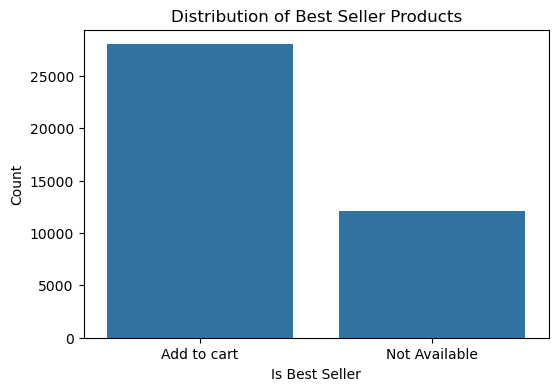

In [91]:
# Count plot
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='buy_box_availability'
)
plt.title('Distribution of Best Seller Products')
plt.xlabel('Is Best Seller')
plt.ylabel('Count')
plt.show()

In [92]:
# Percentage Distribution
category_percentage = (
    df['buy_box_availability']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
category_percentage.columns = ['buy_box_availability', 'Percentage (%)']
category_percentage

,buy_box_availability,Percentage (%)
0,Add to cart,69.82
1,Not Available,30.18


In [93]:
# missing value
df['buy_box_availability'].isnull().sum()/len(df['buy_box_availability'])*100

np.float64(0.0)

#### delivery_day
**conclusions**

- most common day for delivery is `Thursday`
- 23% missing values

In [94]:
# Value Counts
df['delivery_day'].value_counts()

delivery_day
Thursday     11701
Monday        7241
Wednesday     5285
Tuesday       4925
Friday        1215
Saturday       324
Sunday           1
Name: count, dtype: int64

In [95]:
# Percentage Distribution
category_percentage = (
    df['delivery_day']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
category_percentage.columns = ['delivery_day', 'Percentage (%)']
category_percentage

,delivery_day,Percentage (%)
0,Thursday,38.12
1,Monday,23.59
2,Wednesday,17.22
3,Tuesday,16.05
4,Friday,3.96
5,Saturday,1.06
6,Sunday,0.00


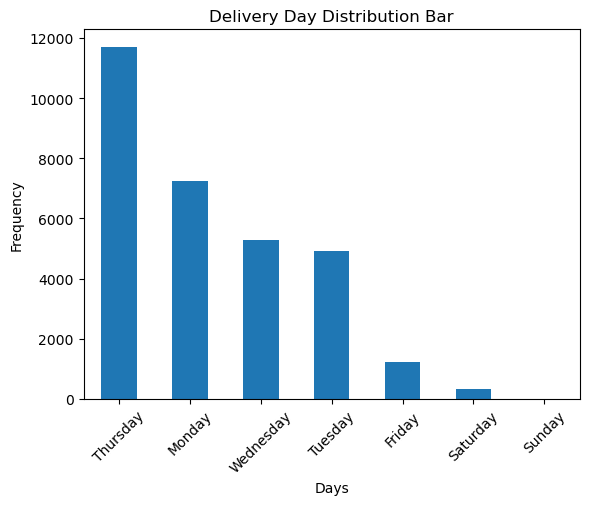

In [105]:
# Distribution chart
df['delivery_day'].value_counts().plot(kind='bar')
plt.title('Delivery Day Distribution Bar')
plt.xlabel('Days')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()

In [104]:
# missing value
df['delivery_day'].isnull().sum()/len(df['delivery_day'])*100

np.float64(23.528092687180767)

#### delivery_month
**conclusions**

- only september and august month data present
- 98% value of delivery_month is septmeber
- 23% missing values

In [106]:
# Value Counts
df['delivery_month'].value_counts()

delivery_month
September    30276
August         416
Name: count, dtype: int64

In [107]:
# Percentage Distribution
category_percentage = (
    df['delivery_month']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
category_percentage.columns = ['delivery_month', 'Percentage (%)']
category_percentage

,delivery_month,Percentage (%)
0,September,98.64
1,August,1.36


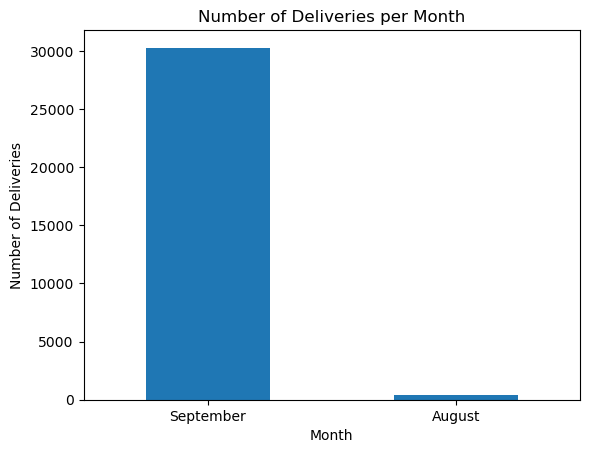

In [125]:
# Distribution chart
df['delivery_month'].value_counts().plot(kind='bar')
plt.title("Number of Deliveries per Month")
plt.xlabel("Month")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=0)
plt.show()

In [115]:
# missing value
df['delivery_month'].isnull().sum()/len(df['delivery_month'])*100

np.float64(23.528092687180767)

### Datetime column

#### delivery_date
**conclusions**

- most
- Almost 7800+ delivery happend on 4th of september
- 23% missing values

In [121]:
# Earliest and latest delivery dates
print("Earliest Delivery Date :", df["delivery_date"].min())
print("Latest Delivery Date   :", df["delivery_date"].max())

Earliest Delivery Date : 2025-08-27 00:00:00
Latest Delivery Date   : 2025-09-29 00:00:00


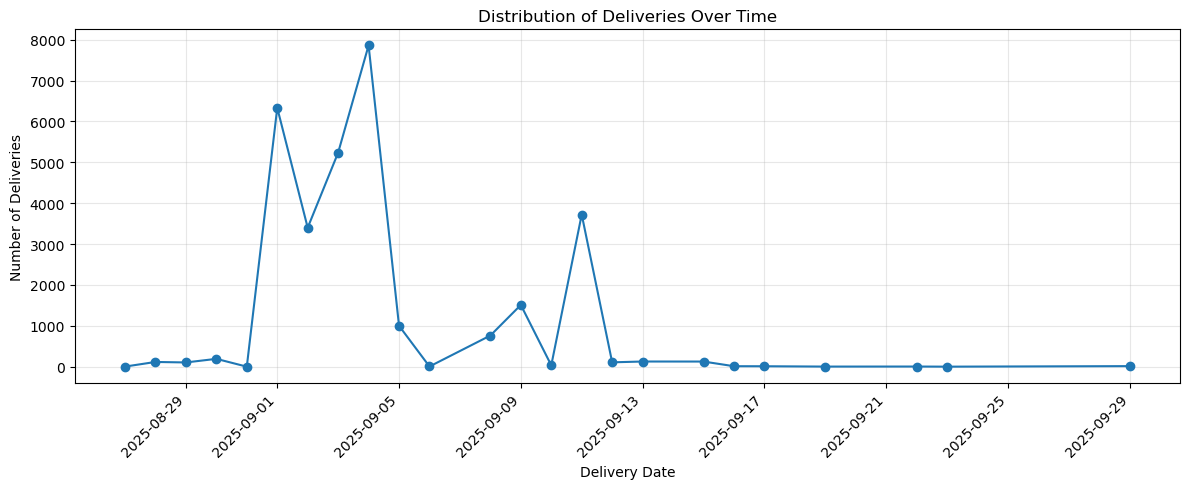

In [122]:
# Distribution of Deliveries Over Time (Line Plot)

# Count deliveries by date
delivery_trend = (
    df['delivery_date'].value_counts().sort_index()
)

# Line plot
plt.figure(figsize=(12,5))

delivery_trend.plot(
    kind='line',
    marker='o'
)

plt.title("Distribution of Deliveries Over Time")
plt.xlabel("Delivery Date")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [130]:
# missing values
missing_date_analysis = pd.DataFrame({
    "Metric": ["Missing Values", "Missing Percentage"],
    "Value": [
        df["delivery_date"].isna().sum(),
        f"{df['delivery_date'].isna().mean() * 100:.2f}%"
    ]
})
missing_date_analysis

,Metric,Value
0,Missing Values,9443
1,Missing Percentage,23.53%


In [132]:
delivery_trend.sort_values(ascending=False)

delivery_date
2025-09-04    7862
2025-09-01    6334
2025-09-03    5238
2025-09-11    3723
2025-09-02    3401
2025-09-09    1511
2025-09-05    1001
2025-09-08     763
2025-08-30     192
2025-09-13     127
2025-09-15     126
2025-08-28     116
2025-09-12     107
2025-08-29     104
2025-09-10      33
2025-09-29      14
2025-09-16      12
2025-09-17      11
2025-09-06       5
2025-09-22       4
2025-09-19       3
2025-08-27       3
2025-08-31       1
2025-09-23       1
Name: count, dtype: int64